# Driver Classification — Protocol 1 (4-Quarter Stack)
**Fixes included**: GEE spatial mismatch corrected at both save-time (data prep) and load-time (dataloader defensive guard).

**Training year**: 2025 composites  |  **GT year**: 2024

## 0 · Setup

In [1]:
!pip install rasterio imagecodecs scikit-image scikit-learn -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.7/24.7 MB 49.3 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import sys
sys.path.append('/content/drive/MyDrive/A_Thesis')

import os, glob, random
import numpy as np
import rasterio
import tensorflow as tf
from skimage.util import random_noise

from utils_b import (
    fix_random_seeds, check_folder, plot_history,
    get_class_weights, softmax_with_temperature,
    CustomMacroF1Score, custom_categorical_crossentropy,
)
from resunet import res_unet

fix_random_seeds(42)
print('TF:', tf.__version__)

TF: 2.19.0


## 1 · Configuration


In [6]:
# ── Paths (Colab / Drive) ────────────────────────────────────────────────
DRIVE_ROOT = '/content/drive/MyDrive'
IMG_ROOT   = os.path.join(DRIVE_ROOT, 'Final_GEE_Exports')
GT_ROOT    = os.path.join(DRIVE_ROOT,
             'GEE_Exports quarter_only/Driver_test/clipped_outputs')
DATA_DIR   = '/content/data'
EXP_DIR    = '/content/exp'
# ── AOI universe ─────────────────────────────────────────────────────────
ALL_AOIS       = [f'AOI_{i}' for i in range(10)]
REQUIRED_DRIVERS = {1, 2, 3}

# ── Temporal ─────────────────────────────────────────────────────────────
INPUT_YEAR     = '2025'
GT_YEAR        = '2024'
QUARTER_MONTHS = [f'{INPUT_YEAR}_M03', f'{INPUT_YEAR}_M06',
                  f'{INPUT_YEAR}_M09', f'{INPUT_YEAR}_M12']

# ── Bands / classes ───────────────────────────────────────────────────────
TOTAL_BANDS    = 6
NB_CLASSES     = 4

# ── Training (light test defaults) ────────────────────────────────────────
SIZE_CROPS      = 256        # prod: 256
BATCH_SIZE      = 2         # prod: 5
N_SAMPLES_TRAIN = 20        # prod: 1000
N_SAMPLES_VAL   = 10        # prod: 500
EPOCHS          = 3         # prod: 50
BASE_LR         = 3e-4
FINAL_LR        = 1e-6
TEMPERATURE     = 300
AUGMENT         = False     # prod: True

for d in [DATA_DIR, EXP_DIR,
          os.path.join(DATA_DIR,'train'), os.path.join(DATA_DIR,'test')]:
    os.makedirs(d, exist_ok=True)
print('Config OK')
print(f'  {INPUT_YEAR} quarters: {QUARTER_MONTHS}')
print(f'  effective bands: {TOTAL_BANDS}×{len(QUARTER_MONTHS)}={TOTAL_BANDS*len(QUARTER_MONTHS)}')


Config OK
  2025 quarters: ['2025_M03', '2025_M06', '2025_M09', '2025_M12']
  effective bands: 6×4=24


## 2 · Helper functions
Data-prep helpers, driver audit, and the dataloader class are defined here.
The **spatial mismatch fix** is in `align_gt_to_image()` (save-time)
and the defensive guard inside `MemmapNPYCropDataset.generator()` (load-time).

In [7]:
def load_monthly_stack(aoi, img_root, month_labels, total_bands):
    """
    Load monthly composite TIF files for one AOI and stack them.
    File pattern: <img_root>/AOI_N/AOI_N_YYYY_MNN.tif
    Returns: np.ndarray (T, H, W, B) float32, list of loaded labels
    """
    aoi_folder = os.path.join(img_root, aoi)
    images, loaded_labels = [], []
    for label in month_labels:
        fpath = os.path.join(aoi_folder, f'{aoi}_{label}.tif')
        if not os.path.exists(fpath):
            print(f'    ⚠  Missing: {os.path.basename(fpath)} — skipping')
            continue
        with rasterio.open(fpath) as src:
            arr = src.read().transpose(1, 2, 0).astype(np.float32)  # (H,W,B)
        images.append(arr)
        loaded_labels.append(label)
    if not images:
        raise FileNotFoundError(
            f'No composites found for {aoi} in {aoi_folder}')
    stack = np.stack(images, axis=0)   # (T, H, W, B)
    print(f'  [{aoi}] loaded {len(images)} months → {stack.shape}')
    return stack, loaded_labels


def load_gt(aoi, gt_root):
    """Load and remap driver GT. Classes: 1=bb 2=fm 3=wt 0=bg 255=nodata."""
    gt_path = os.path.join(gt_root, f'{aoi}_drivers.tif')
    with rasterio.open(gt_path) as src:
        gt = src.read(1).astype(np.uint8)
    gt[(gt != 1) & (gt != 2) & (gt != 3) & (gt != 255)] = 0
    print(f'  [{aoi}] GT {gt.shape}  classes: {np.unique(gt[gt!=255])}')
    return gt


def align_gt_to_image(stack, gt, aoi):
    """
    Crop GT to exactly match the image spatial dims.

    GEE exports image and GT in separate operations; CRS rounding can make
    them differ by a few pixels.  We fix this at SAVE TIME so the .npy files
    on disk are always spatially consistent.  The dataloader has a second
    defensive guard for any files saved before this fix was introduced.
    """
    H_img, W_img = stack.shape[1], stack.shape[2]
    H_gt,  W_gt  = gt.shape

    if (H_gt, W_gt) == (H_img, W_img):
        return gt   # already aligned

    # Intersect to common region
    h = min(H_img, H_gt)
    w = min(W_img, W_gt)
    gt = gt[:h, :w]

    # Zero-pad gt up to image size if image is larger
    if h < H_img or w < W_img:
        gt = np.pad(gt, ((0, H_img - h), (0, W_img - w)),
                    constant_values=0)

    if (H_gt, W_gt) != (H_img, W_img):
        print(f'  ⚠  [{aoi}] spatial mismatch fixed: '
              f'GT ({H_gt},{W_gt}) → image ({H_img},{W_img})')
    return gt


def audit_aoi_drivers(gt_root, all_aois, required=None):
    """Return (complete_aois, incomplete_list) based on driver class coverage."""
    if required is None:
        required = {1, 2, 3}
    complete, incomplete = [], []
    for aoi in all_aois:
        candidates = [os.path.join(gt_root, f'{aoi}_drivers.tif'),
                      os.path.join(gt_root, f'{aoi}_gt.npy')]
        gt_path = next((p for p in candidates if os.path.exists(p)), None)
        if gt_path is None:
            print(f'  ⚠  {aoi}: no GT file found')
            incomplete.append((aoi, required))
            continue
        if gt_path.endswith('.tif'):
            with rasterio.open(gt_path) as src:
                arr = src.read(1).astype(np.int16)
        else:
            arr = np.load(gt_path).astype(np.int16)
        valid   = arr[arr != 255]
        present = set(int(v) for v in np.unique(valid))
        missing = required - present
        (incomplete if missing else complete).append(
            (aoi, missing) if missing else aoi)
    return complete, incomplete


In [8]:
import numpy as np
import tensorflow as tf
import random
from skimage.util import random_noise


class MemmapNPYCropDataset(tf.data.Dataset):
    """
    Random-crop tf.data.Dataset from pre-saved .npy stacks.

    Input .npy shape : (T, H, W, B)  — T timesteps, B bands each
    Output crop      : (tile_size, tile_size, T*B)

    Spatial mismatch fix
    --------------------
    GEE exports image composites and GT rasters in separate operations.
    CRS rounding during reprojection can make them differ by a few pixels.
    The fix is applied in TWO places so it is robust regardless of whether
    the .npy files were saved before or after the fix was introduced:

      1. data_preparation.py  — crops GT to image dims at SAVE time
         (prevents mismatch from ever entering the .npy files)

      2. This generator        — re-checks and reconciles at LOAD time
         (defensive guard for any pre-existing .npy files on disk)
    """

    def __new__(cls, image_paths, gt_paths, times_steps,
                tile_size, batch_size, total_feat, samples, augment, protocol):

        n_timesteps    = len(times_steps)
        effective_feat = total_feat * n_timesteps

        def load_and_stack(img_full):
            selected = img_full[times_steps]
            if selected.ndim == 3:
                return np.moveaxis(selected, 0, -1).astype(np.float32)
            elif selected.ndim == 4:
                T, H, W, B = selected.shape
                return selected.transpose(1, 2, 0, 3).reshape(H, W, T*B).astype(np.float32)
            else:
                raise ValueError(f"Unexpected ndim={selected.ndim}")

        def generator():
            for _ in range(samples):
                file_idx = np.random.randint(0, len(image_paths))
                img_full = np.load(image_paths[file_idx])
                ref      = np.load(gt_paths[file_idx])

                img = load_and_stack(img_full)          # (H, W, T*B)
                img_h, img_w, _ = img.shape
                ref_h, ref_w    = ref.shape

                # ── Spatial reconciliation (defensive, load-time guard) ────
                # Fixes: TypeError: generator yielded shape (64,59)
                #        expected (64,64)
                # Root cause: GEE CRS rounding makes image/GT differ by
                # a few pixels even when clipped to the same AOI polygon.
                if (ref_h, ref_w) != (img_h, img_w):
                    # Crop both to the intersection (safe common region)
                    h = min(img_h, ref_h)
                    w = min(img_w, ref_w)
                    img = img[:h, :w, :]
                    ref = ref[:h, :w]
                    # Zero-pad ref back up to img size if img was larger
                    ph, pw = img_h - h, img_w - w
                    if ph > 0 or pw > 0:
                        ref = np.pad(ref, ((0, ph), (0, pw)),
                                     constant_values=0)
                    img_h, img_w = h, w

                tile_h, tile_w = img_h, img_w

                # ── Pad to tile_size if AOI is smaller than crop ──────────
                if tile_h < tile_size or tile_w < tile_size:
                    ph = max(0, tile_size - tile_h)
                    pw = max(0, tile_size - tile_w)
                    img = np.pad(img, ((0,ph),(0,pw),(0,0)), constant_values=0)
                    ref = np.pad(ref, ((0,ph),(0,pw)),       constant_values=0)
                    tile_h, tile_w, _ = img.shape

                # ── Random crop ───────────────────────────────────────────
                r = np.random.randint(0, tile_h - tile_size + 1)
                c = np.random.randint(0, tile_w - tile_size + 1)
                crop_img = img[r:r+tile_size, c:c+tile_size, :].copy().astype(np.float32)
                crop_ref = ref[r:r+tile_size, c:c+tile_size  ].copy().astype(np.float32)

                if np.all(crop_ref == 255):
                    continue

                # ── Augmentation ──────────────────────────────────────────
                if augment:
                    if random.random() < 0.5:
                        crop_img = np.fliplr(crop_img)
                        crop_ref = np.fliplr(crop_ref)
                    if random.random() < 0.5:
                        for t in range(n_timesteps):
                            s = t * total_feat
                            crop_img[..., s:s+2] = random_noise(
                                crop_img[..., s:s+2],
                                mode='gaussian', clip=True).astype(np.float32)

                yield crop_img, crop_ref

        output_signature = (
            tf.TensorSpec(shape=(tile_size, tile_size, effective_feat), dtype=tf.float32),
            tf.TensorSpec(shape=(tile_size, tile_size),                  dtype=tf.float32),
        )
        ds = tf.data.Dataset.from_generator(generator, output_signature=output_signature)
        return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)


class InferenceDataloader(tf.keras.utils.Sequence):
    def __init__(self, image, input_bands, band_label, batch_size, psize, coordinates):
        self.input_bands = input_bands
        self.band_label  = band_label
        self.batch_size  = batch_size
        self.image       = image
        self.coordinates = coordinates
        self.psize       = psize

    def __len__(self):
        return int(np.ceil(len(self.coordinates) / self.batch_size))

    def __getitem__(self, index):
        batch = self.coordinates[index*self.batch_size:(index+1)*self.batch_size]
        X, Y  = [], []
        for x, y in batch:
            p = self.psize
            d = self.image[x-p//2:x+p//2+p%2, y-p//2:y+p//2+p%2, :]
            X.append(d[:, :, self.input_bands])
            Y.append(d[..., self.band_label])
        return np.array(X), np.array(Y)

print('Dataloader class defined')

Dataloader class defined


## 3 · AOI Driver Audit

In [9]:
complete_aois, incomplete_aois = audit_aoi_drivers(GT_ROOT, ALL_AOIS, REQUIRED_DRIVERS)

print('\n' + '='*55)
print('AOI DRIVER AUDIT')
print('='*55)
print(f'  ✓ Complete   ({len(complete_aois)}): {complete_aois}')
print(f'  ✗ Incomplete ({len(incomplete_aois)}):')
for aoi, miss in incomplete_aois:
    print(f'      {aoi}  — missing: {miss}')

if len(complete_aois) < 2:
    raise RuntimeError(f'Need ≥2 complete AOIs, found: {complete_aois}')

TRAIN_AOI = complete_aois[0]
TEST_AOI  = complete_aois[1]
print(f'\n  → TRAIN: {TRAIN_AOI}')
print(f'  → TEST : {TEST_AOI}')



AOI DRIVER AUDIT
  ✓ Complete   (7): ['AOI_2', 'AOI_3', 'AOI_4', 'AOI_5', 'AOI_6', 'AOI_7', 'AOI_9']
  ✗ Incomplete (3):
      AOI_0  — missing: {2}
      AOI_1  — missing: {2}
      AOI_8  — missing: {3}

  → TRAIN: AOI_2
  → TEST : AOI_3


## 4 · Data Preparation
> **`align_gt_to_image()` is called here** — this is the primary fix.
> It ensures the `.npy` files saved to disk have exactly matching spatial dims.
> **Re-run this cell** if you previously saved `.npy` files and are hitting the shape error.

In [13]:
def load_monthly_stack(aoi, img_root, month_labels, total_band, drive_root = DRIVE_ROOT ):
    """
    Load monthly composite TIF files for one AOI and stack them.

    File naming: <img_root>/AOI_N/AOI_N_YYYY_MNN.tif
    Returns: np.ndarray  shape (T, H, W, B)  float32
             list of str  month labels that were actually loaded
    """
    aoi_folder = os.path.join(DRIVE_ROOT, f'Final_GEE_Exports {aoi}')
    print(aoi_folder)
    images, loaded_labels = [], []

    for label in month_labels:
        fpath = os.path.join(aoi_folder, f'{aoi}_{label}.tif')
        if not os.path.exists(fpath):
            print(f'    ⚠  Missing: {fpath} — skipping month {label}')
            continue
        with rasterio.open(fpath) as src:
            # Read all bands: shape (B, H, W) → transpose to (H, W, B)
            arr = src.read().transpose(1, 2, 0).astype(np.float32)
        images.append(arr)
        loaded_labels.append(label)

    if not images:
        raise FileNotFoundError(
            f'No monthly composites found for {aoi} in {aoi_folder}\n'
            f'Expected labels: {month_labels}')

    stack = np.stack(images, axis=0)   # (T, H, W, B)
    print(f'  [{aoi}] loaded {len(images)} months → stack shape: {stack.shape}')
    return stack, loaded_labels


def load_gt(aoi, gt_root):
    """
    Load and remap ground-truth for one AOI.
    Driver classes: 1=bb, 2=fm, 3=wt  |  0=background  |  255=nodata
    Everything else → 0.
    """
    gt_path = os.path.join(gt_root, f'{aoi}_drivers.tif')
    with rasterio.open(gt_path) as src:
        gt = src.read(1).astype(np.uint8)
    gt[(gt != 1) & (gt != 2) & (gt != 3) & (gt != 255)] = 0
    print(f'  [{aoi}] GT shape: {gt.shape}  '
          f'classes present: {np.unique(gt[gt!=255])}')
    return gt


def verify_spatial_match(stack, gt, aoi):
    """Warn if image and GT spatial dims differ (CRS mismatch / export issue)."""
    H_img, W_img = stack.shape[1], stack.shape[2]
    H_gt,  W_gt  = gt.shape
    if (H_img, W_img) != (H_gt, W_gt):
        print(f'  ⚠  [{aoi}] SIZE MISMATCH — '
              f'image ({H_img},{W_img}) vs GT ({H_gt},{W_gt}). '
              f'Cropping GT to image size.')
        gt = gt[:H_img, :W_img]
    return gt

In [14]:
print('=' * 55)
print('DATA PREPARATION')
print('=' * 55)

all_labels = []      # training pixel labels for class-weight computation
loaded_time_steps = None   # filled from first AOI

for aoi, split in [(TRAIN_AOI, 'train'), (TEST_AOI, 'test')]:
    print(f'\n── {aoi}  ({split}) ──────────────────────────────────')

    # 1. Load 4 quarter-months for 2025
    stack, ts_labels = load_monthly_stack(
        aoi, IMG_ROOT, QUARTER_MONTHS, TOTAL_BANDS)

    # 2. Record time-step labels once
    if loaded_time_steps is None:
        loaded_time_steps = ts_labels

    # 3. Load & remap 2024 ground-truth
    gt = load_gt(aoi, GT_ROOT)
    gt = verify_spatial_match(stack, gt, aoi)

    # 4. Save .npy arrays
    out_dir = os.path.join(DATA_DIR, split)
    np.save(os.path.join(out_dir, f'{aoi}_input.npy'), stack)
    np.save(os.path.join(out_dir, f'{aoi}_gt.npy'),    gt)
    print(f'  Saved → {out_dir}/{aoi}_input.npy  {stack.shape}')
    print(f'  Saved → {out_dir}/{aoi}_gt.npy     {gt.shape}')

    # 5. Accumulate training labels (skip test AOI and nodata)
    if split == 'train':
        valid = gt[gt != 255]
        all_labels.extend(valid.tolist())

# 6. Save shared meta-arrays
np.save(os.path.join(DATA_DIR, 'labels.npy'),
        np.array(all_labels, dtype=np.int32))
np.save(os.path.join(DATA_DIR, 'time_steps.npy'),
        np.array(loaded_time_steps))

print(f'\ntime_steps saved : {loaded_time_steps}')
print(f'labels saved     : {len(all_labels)} pixels')
print(f'unique labels    : {np.unique(all_labels)}')

DATA PREPARATION

── AOI_2  (train) ──────────────────────────────────
/content/drive/MyDrive/Final_GEE_Exports AOI_2
  [AOI_2] loaded 4 months → stack shape: (4, 3277, 5001, 6)
  [AOI_2] GT shape: (3435, 3444)  classes present: [0 1 2 3]
  ⚠  [AOI_2] SIZE MISMATCH — image (3277,5001) vs GT (3435,3444). Cropping GT to image size.
  Saved → /content/data/train/AOI_2_input.npy  (4, 3277, 5001, 6)
  Saved → /content/data/train/AOI_2_gt.npy     (3277, 3444)

── AOI_3  (test) ──────────────────────────────────
/content/drive/MyDrive/Final_GEE_Exports AOI_3
  [AOI_3] loaded 4 months → stack shape: (4, 3279, 5001, 6)
  [AOI_3] GT shape: (3512, 3521)  classes present: [0 1 2 3]
  ⚠  [AOI_3] SIZE MISMATCH — image (3279,5001) vs GT (3512,3521). Cropping GT to image size.
  Saved → /content/data/test/AOI_3_input.npy  (4, 3279, 5001, 6)
  Saved → /content/data/test/AOI_3_gt.npy     (3279, 3521)

time_steps saved : ['2025_M03', '2025_M06', '2025_M09', '2025_M12']
labels saved     : 11285988 pixels


## 5 · Build Datasets

In [15]:
# Load meta-arrays
labels_train = np.load(os.path.join(DATA_DIR, 'labels.npy'))
time_steps   = np.load(os.path.join(DATA_DIR, 'time_steps.npy'))
print('time_steps:', time_steps)

# Protocol 1 — all 4 saved composites
times_idx       = np.arange(len(time_steps))
n_timesteps     = len(times_idx)
effective_bands = TOTAL_BANDS * n_timesteps
print(f'Protocol 1: {time_steps[times_idx]}')
print(f'Effective channels: {TOTAL_BANDS} × {n_timesteps} = {effective_bands}')

# Discover .npy paths
imgs_train = sorted(glob.glob(os.path.join(DATA_DIR, 'train', '*input.npy')))
gt_train   = sorted(glob.glob(os.path.join(DATA_DIR, 'train', '*gt.npy')))
imgs_test  = sorted(glob.glob(os.path.join(DATA_DIR, 'test',  '*input.npy')))
gt_test    = sorted(glob.glob(os.path.join(DATA_DIR, 'test',  '*gt.npy')))
print(f'Train: {[os.path.basename(p) for p in imgs_train]}')
print(f'Test : {[os.path.basename(p) for p in imgs_test]}')

# Class weights
weights_train = get_class_weights(labels_train)
for c in range(NB_CLASSES):
    if c not in weights_train:
        weights_train[c] = 1.0
        print(f'  Class {c} absent → weight 1.0')
weights_train = dict(sorted(weights_train.items()))
values        = np.array(list(weights_train.values()))
weights_train = dict(zip(weights_train.keys(),
                         softmax_with_temperature(values, TEMPERATURE)))
print('Scaled weights:', weights_train)

# Build datasets
train_dataset = MemmapNPYCropDataset(
    image_paths=imgs_train, gt_paths=gt_train,
    times_steps=times_idx,  tile_size=SIZE_CROPS,
    batch_size=BATCH_SIZE,  total_feat=TOTAL_BANDS,
    samples=N_SAMPLES_TRAIN, augment=AUGMENT, protocol=1)

dev_dataset = MemmapNPYCropDataset(
    image_paths=imgs_test, gt_paths=gt_test,
    times_steps=times_idx, tile_size=SIZE_CROPS,
    batch_size=BATCH_SIZE, total_feat=TOTAL_BANDS,
    samples=N_SAMPLES_VAL, augment=False, protocol=1)

print('\nDatasets built. Verifying batch shapes...')
for x_b, y_b in train_dataset.take(1):
    print(f'  x: {x_b.shape}  expected ({BATCH_SIZE},{SIZE_CROPS},{SIZE_CROPS},{effective_bands})')
    print(f'  y: {y_b.shape}  expected ({BATCH_SIZE},{SIZE_CROPS},{SIZE_CROPS})')
    assert x_b.shape == (BATCH_SIZE, SIZE_CROPS, SIZE_CROPS, effective_bands), "x shape mismatch!"
    assert y_b.shape == (BATCH_SIZE, SIZE_CROPS, SIZE_CROPS),                  "y shape mismatch!"
print('✓ Shape check passed')


time_steps: ['2025_M03' '2025_M06' '2025_M09' '2025_M12']
Protocol 1: ['2025_M03' '2025_M06' '2025_M09' '2025_M12']
Effective channels: 6 × 4 = 24
Train: ['AOI_2_input.npy']
Test : ['AOI_3_input.npy']
Scaled weights: {0: np.float64(3.328994403509708e-102), 1: np.float64(4.8330016215241234e-101), 2: np.float64(9.656863276902873e-98), 3: np.float64(1.0)}

Datasets built. Verifying batch shapes...
  x: (2, 256, 256, 24)  expected (2,256,256,24)
  y: (2, 256, 256)  expected (2,256,256)
✓ Shape check passed


## 6 · Model

In [16]:
filters     = [32, 32, 32, 32]   # prod: [64,128,256,512]
kernel_size = 3

model = res_unet(SIZE_CROPS, filters, kernel_size, effective_bands, NB_CLASSES)

losses  = {'fus': custom_categorical_crossentropy(weights_train)}
metrics = {'fus': [CustomMacroF1Score(NB_CLASSES)]}
model.compile(optimizer=tf.keras.optimizers.Adam(BASE_LR),
              loss=losses, metrics=metrics)
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 256, 256,  │          0 │ -                 │
│                     │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer1_1 (Conv2D)   │ (None, 256, 256,  │      6,944 │ input[0][0]       │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256, 256,  │        128 │ layer1_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer1_shortcut     │ (None, 256, 256,  │        800 │ input[0][0]       │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        128 │ layer1_shortcut[… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer1_2 (Conv2D)   │ (None, 256, 256,  │      9,248 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 256, 256,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │ layer1_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        128 │ add[0][0]         │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_layer1_1    │ (None, 128, 128,  │      9,248 │ activation_1[0][… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        128 │ encoder_layer1_1… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_layer1_sho… │ (None, 128, 128,  │      1,056 │ add[0][0]         │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        128 │ encoder_layer1_s… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_layer1_2    │ (None, 128, 128,  │      9,248 │ activation_2[0][… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 128, 128,  │          0 │ batch_normalizat

 Total params: 324,612 (1.24 MB)

 Trainable params: 322,372 (1.23 MB)

 Non-trainable params: 2,240 (8.75 KB)

## 7 · Training

In [18]:
from keras.callbacks import CSVLogger

os.makedirs(EXP_DIR, exist_ok=True)
ckpt_path = os.path.join(EXP_DIR, 'checkpoint.weights.h5')

monitor = 'val_custom_macro_f1_score'

callbacks = [
    CSVLogger(os.path.join(EXP_DIR, 'log.log'), append=True, separator=';'),
    tf.keras.callbacks.ModelCheckpoint(
        filepath=ckpt_path, save_weights_only=True,
        monitor=monitor, mode='max', save_best_only=True),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor=monitor, factor=0.25, min_delta=0.001,
        patience=15, cooldown=0, min_lr=FINAL_LR, verbose=1),
    tf.keras.callbacks.EarlyStopping(
        monitor=monitor, min_delta=0.001, patience=20,
        mode='max', restore_best_weights=False, verbose=1),
]

history = model.fit(
    train_dataset,
    validation_data=dev_dataset,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1,
)

model.save(os.path.join(EXP_DIR, 'model.h5'))
print('\nModel saved →', os.path.join(EXP_DIR, 'model.h5'))


Epoch 1/3
     10/Unknown 284s 26s/step - custom_macro_f1_score: 0.0937 - loss: 0.0000e+00

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


10/10 ━━━━━━━━━━━━━━━━━━━━ 391s 38s/step - custom_macro_f1_score: 0.0935 - loss: 0.0000e+00 - val_custom_macro_f1_score: 4.3484e-05 - val_loss: 0.0000e+00 - learning_rate: 3.0000e-04
Epoch 2/3
10/10 ━━━━━━━━━━━━━━━━━━━━ 394s 40s/step - custom_macro_f1_score: 0.0887 - loss: 7.8032e-05 - val_custom_macro_f1_score: 6.3316e-05 - val_loss: 0.0000e+00 - learning_rate: 3.0000e-04
Epoch 3/3
10/10 ━━━━━━━━━━━━━━━━━━━━ 382s 39s/step - custom_macro_f1_score: 0.0771 - loss: 3.1678e-06 - val_custom_macro_f1_score: 2.7466e-05 - val_loss: 0.0000e+00 - learning_rate: 3.0000e-04



Model saved → /content/exp/model.h5


## 8 · Results

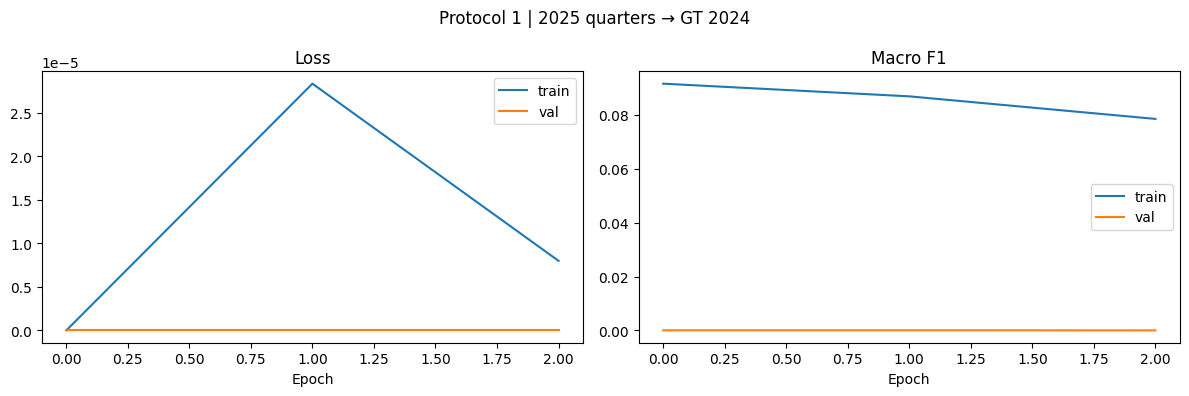

Plot saved → /content/exp/history.png


In [19]:
import matplotlib.pyplot as plt

h   = history.history
def _k(base):
    for cand in [f'fus_{base}', base]:
        if cand in h: return cand
    raise KeyError(f'{base} not in history: {list(h.keys())}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(h[_k('loss')],     label='train')
axes[0].plot(h[_k('val_loss')], label='val')
axes[0].set_title('Loss'); axes[0].legend(); axes[0].set_xlabel('Epoch')

axes[1].plot(h[_k('custom_macro_f1_score')],     label='train')
axes[1].plot(h[_k('val_custom_macro_f1_score')], label='val')
axes[1].set_title('Macro F1'); axes[1].legend(); axes[1].set_xlabel('Epoch')

plt.suptitle(f'Protocol 1 | {INPUT_YEAR} quarters → GT {GT_YEAR}', fontsize=12)
plt.tight_layout()
fig.savefig(os.path.join(EXP_DIR, 'history.png'), dpi=150)
plt.show()
print('Plot saved →', os.path.join(EXP_DIR, 'history.png'))
